# Miniproyecto 3: ¿Te gustaría ser *Data Scientist Senior*?
#### **Curso:** Introducción a Minería de Datos y Machine Learning

---

**¡Tienes una oferta de trabajo!**

Una empresa se enteró de tu **excelente** trabajo como *Data Scientist Junior* en **AMAZOFF**.

¡Quieren que trabajes con ellos como ***Data Scientist Senior***!

Para la entrevista de trabajo, te han pedido que utilices tus poderes de ***Machine Learning*** en sus bases de datos.

**¿Estás listo para el reto?**

# ¿Qué empresa te quiere en su equipo?

En este MP3 deberás buscar una base de datos y aplicar tus conocimientos de *Machine Learning*.

Una vez elegida la base de datos, deberás inventar una empresa ficticia que te busca para el puesto de *Data Scientist Senior*.

La empresa debe de tener sentido con los datos y lo que quieres predecir usando *Machine Learning*.

## ¿Cómo elegir la base de datos?

Puedes utilizar cualquier base de datos que esté publicada en internet de forma libre. Esta base de datos debe por lo menos cumplir con:

- Tener al menos 1000 filas después de limpiarla.
- Tener al menos 5 columnas con información relevante (no cuentan: *ids*, *index*, etc.) después de limpiarla.
- No tener consideraciones éticas graves. Ejemplo: datos privados de una empresa real.
- Debe tener al menos una columna (aparte de las 5 relevantes) para predecir (columna `label`o `target`).
- El ejercio contempla solo una base de datos. Si tus datos vienen originalmente en más de una, deberás juntarlos (ejemplo: `join`, `merge`, etc.) en la pregunta 1. Debes cargar todos los datos necesarios en la sección de **Preámbulo**.

# Define tu empresa

> **¡No olvides elegir tus datos primero!**

- **Nombre de la empresa**: [ TERRENAL GYM ]
- **Descripción de la empresa**: [ **Terrenal Gym** es una cadena de gimnasios que busca acercar el entrenamiento físico a la vida diaria de las personas. Nuestro enfoque es crear espacios accesibles y cercanos, donde los clientes puedan combinar salud, bienestar y comunidad.  Actualmente, Terrenal Gym enfrenta el reto de mejorar la **retención de clientes**: algunos usuarios abandonan sus contratos tras pocos meses, mientras que otros permanecen leales por largo tiempo.  Por esta razón, hemos recopilado datos demográficos, contractuales y de uso de nuestros clientes, con el objetivo de analizar patrones de comportamiento, entender las causas del abandono (churn) y diseñar estrategias para aumentar la fidelización. Este análisis servirá como una base sólida para tomar decisiones estratégicas que fortalezcan la permanencia de nuestros clientes y maximicen el valor de Terrenal Gym en el mercado fitness. ]

# Pauta de Evaluación

Este MP3 está enfocado en responder preguntas de negocio relevantes para tu nueva empresa (creada por ti).

### Preguntas de Negocio

1. (10 puntos) ¿Cargaste los datos? ¡Toca limpiarlos! La empresa no ha tocado esos datos. ¿Se los puedes explicar?
2. (15 puntos) Datos limpios. Pues, es hora de un... ¡Análisis Exploratorio de Datos!
3. (10 puntos) ¡Vamos con el ML... ¿Qué? ¿Hay que preparar los datos primero?
4. (20 puntos) ¡Grupos everywhere!
5. (25 puntos) ¿Podemos predecir algo con estos datos? Demostremos nuestra experiencia.
6. (20 puntos) ¿Puedes explicar mejor tus resultados? ¡De Junior a Senior!

### Tener en consideración:

En caso de que el código esté bien, pero no se responda (usando celdas de texto) la pregunta de negocio (sección **Explicación**), **se asignará máximo la mitad de puntos** de esa pregunta.

> # ¡NO OLVIDES GUARDAR Y SUBIR EL NOTEBOOK A LA PLATAFORMA CUANDO TERMINES! FORMATO .ipynb

> # ¡NO OLVIDES SUBIR LOS DATOS ORIGINALES A LA PLATAFORMA!

# Preámbulo

In [72]:
# Agrega todas las librerias necesarias para el proyecto en su sección correspondiente

# Clustering
from sklearn.cluster import KMeans

# Machine Learning
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# General Data Science
import statsmodels
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
# Esta configuración permite que los dataframes se muestren completos.
pd.set_option('display.max_columns', None)

In [3]:
# PARÁMETROS (puedes modificar esta sección)

DATA_PATH = "gym_churn_us.csv" # Si tienes el archivo en otro lugar, cámbialo.
RANDOM_STATE = 0 # ¡Cámbialo a tu número favorito!

In [4]:
# Esta celda se encarga de cargar los datos. ¿La necesitas modificar? ¡Adelante!

df = pd.read_csv(DATA_PATH)
print(f'{df.shape[0]} rows x {df.shape[1]} columns')
df.head(5)

4000 rows x 14 columns


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


# Para iniciar con el análisis de la base de datos, se ejecutaron comandos para conocer las dimensiones del dataset, los tipos de datos que contenían las columnas, también para visualizar valores faltantes, duplicados, nulos. Se ejecutó el comando "df.describe().T" para generar estadisticas descriptivas de cada columna y tener una visión rápida de la distribución de los datos númericos.

# Para iniciar el análisis se realizaron distintas verificaciones para conocer el estado previo de la base de datos, como: dimensión del dataset "df.shape", lo que permitió identificar la cantidad de filas y columnas disponibles. Tipos de datos "df.dtypes" para verificar el formato de las variables. Valores faltantes "df.isna().sum()" y valores nulos "df.isnull().sum()". Valores duplicados con "df.duplicated().sum()". Tambien se ejecutó el comando "df.describe().T" para una primera exploración de la distribución de rangos y posibles valores atípicos en las variables numéricas. En esta etapa no fue necesario eliminar columnas ni crear nuevas, ya que la base de datos se encontraba en condiciones adecuadas para avanzar con el análisis.

In [5]:
# ¿Necesitas más celdas antes de empezar a trabajar? ¡Agrega todas las que necesites!
# No olvides que en la pregunta 1 es donde debes hacer la limpieza de datos.

# Dimensión del dataset
print(df.shape)

(4000, 14)


In [6]:
# Tipos de datos
print(df.dtypes)

gender                                 int64
Near_Location                          int64
Partner                                int64
Promo_friends                          int64
Phone                                  int64
Contract_period                        int64
Group_visits                           int64
Age                                    int64
Avg_additional_charges_total         float64
Month_to_end_contract                float64
Lifetime                               int64
Avg_class_frequency_total            float64
Avg_class_frequency_current_month    float64
Churn                                  int64
dtype: object


In [7]:
# Valores faltantes
print(df.isna().sum())

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [8]:
# Valores duplicados
print("\nDuplicados:", df.duplicated().sum())


Duplicados: 0


In [9]:
# Valores nulos
df.isnull().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [10]:
# Estadisticas básicas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


# 1. ¿Cargaste los datos? ¡Toca limpiarlos! La empresa no ha tocado esos datos. ¿Se los puedes explicar?

⁉️ **Consideración:** Asegúrate que no haya datos faltantes, que estén en el formato o tipo de dato correctos, que no haya inconsistencias, que puedas estar seguro que los datos están listos para ser usados. No olvides explicar todas tus decisiones.

ℹ️ **HINT 1:** ¿Necesitas crear nuevas columnas? ¿Tienes datos con muchas categorías? ¿Sobran columnas?

ℹ️ **HINT 2:** Recuerda que esta sección debe cumplir con los criterios para elegir la base de datos. 

ℹ️ **HINT 3:** Toma de inspiración la pregunta 2 del MP1.

---

✅ **Explicación:**

[El dataset contiene información de 4000 clientes de un gimnasio con 14 columnas, se considera variable objetivo: la tasa de cancelación "Churn", que indica si un cliente abandonó el gimnasio (1) o no (0). Las columnas del dataset indican variables contractuales: contract_period, month_to_end_contract, lifetime, demográficas: gender, age. De comportamiento: group_visits, avg_class_frequency_total, financieras: avg_additional_charges_total y de contexto: near_location, partner, promo friends, phone.
En relación a la calidad de los datos, no se encontraron valores duplicados ni faltantes, todas las variables estan en tipos de datos apropiados para procesar: int, float, category. El dataset se encuentra bastante limpio y consistente, Sin embargo se realizaron unas verificaciones para estandarizar y transformar algunas variables.]

In [11]:
# Se realizó una estandarización de nombres de las columnas, pasando las mayúsculas a minúsculas y eliminando espacios en blanco
df.columns = df.columns.str.lower().str.strip()

In [12]:
# En este paso se verificaron los valores únicos de "contract_period" y los rangos de "age" y "lifetime" confirmando que no tengan valores atípicos extremos
print("Contract period únicos:", df["contract_period"].unique())
print("Edad mínima y máxima:", df["age"].min(), "-", df["age"].max())
print("Lifetime mínima y máxima:", df["lifetime"].min(), "-", df["lifetime"].max())

Contract period únicos: [ 6 12  1]
Edad mínima y máxima: 18 - 41
Lifetime mínima y máxima: 0 - 31


In [13]:
# Se transformaron las variables binarias a categóricas para facilitar el análisis exploratorio, reducir memoria y preparar los datos para ML.
bin_cols = ["gender", "near_location", "partner", "promo_friends", 
            "phone", "group_visits"]
for col in bin_cols:
    df[col] = df[col].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   gender                             4000 non-null   category
 1   near_location                      4000 non-null   category
 2   partner                            4000 non-null   category
 3   promo_friends                      4000 non-null   category
 4   phone                              4000 non-null   category
 5   contract_period                    4000 non-null   int64   
 6   group_visits                       4000 non-null   category
 7   age                                4000 non-null   int64   
 8   avg_additional_charges_total       4000 non-null   float64 
 9   month_to_end_contract              4000 non-null   float64 
 10  lifetime                           4000 non-null   int64   
 11  avg_class_frequency_total          4000 non

# 2. Datos limpios. Pues, es hora de un... ¡Análisis Exploratorio de Datos!

⁉️ **Consideración:** ¡Es hora del EDA! Es importante entender muy bien que **información** contienen tus datos. Para esto, considerando las necesidades de tu empresa, plantearás 5 preguntas interesantes para ella que se puedan responder al analizar tus datos.

ℹ️ **HINT 1 :** Busca preguntas relevantes y no triviales. Utiliza gráficos, estadísticas, lo que se ocurra para explotar la información de los datos.

ℹ️ **HINT 2:** Inspírate en las preguntas 3 y 4 del MP1.

---

✅ **Explicación:**

- **Pregunta 1: ¿[TENER AMIGOS REFERIDOS O ACCEDER A PROMOCIONES DISMINUYE LA PROBABILIDAD DE QUE UN CLIENTES CANCELE SU MEMBRESÍA]?**

    [Las estadisticas graficadas muestran que tener referidos o acceder a promociones se asocia a una menor tasa de cancelación, representando la oportunidad para reforzar estas estrategias de fidelización. En el primer gráfico los clientes que no accedieron a promociones presentan una tasa de cancelación del 31%, mientras que los que sí accedieron a una promo cancelaron en un 16%. En relación a inscribirse con el beneficio de partner/friends, en el gráfico se muestra que los clientes que se inscribieron sin un compañero tuvieron una tasa de cancelación de un 33% mientras que los que sí ocuparon la opción de referidos cancelaron solo en un 19%, lo que indica que asistir con alguien más aumenta la probabilidad de permanencia.]

- **Pregunta 2: ¿[ LOS CLIENTES QUE VIVEN CERCA DEL GIMNASIO TIENEN MENOR PROBABILIDAD DE CANCELAR SU MEMBRESÍA QUE LOS QUE VIVEN MÁS LEJOS ]?**

    [ El gráfico circular muestra que del total de clientes que viven lejos, un 39.7% canceló su membresía, mientras que los que viven cerca tuvieron una tasa de cancelación del 24.1%. Estos resultados indican que la ubicación es un factor importante para la retención de clientes. Una solución sería considerar la apertura de sucursales en zonas con mayor concentración de clientes y facilitar el acceso. ]

- **Pregunta 3: ¿[ EXISTE RELACIÓN ENTRE LA EDAD DE LOS CLIENTES Y LA PROBABILIDAD DE QUE ABANDONEN EL GIMNASIO ]?**

    [ El gráfico boxplot muestra la mayor concentracion de cancelaciones en dos rangos etarios muy parecidos, señalando que el grupo más joven tiende a cancelar con más frecuencia. Sin embargo dado a que ambos grupos se concentran en un rango etario similar (entre los 27 y 30 años) se concluye que la edad no es un factor determinante para dar de baja la membresía, en comparación a las variables anteriores. ]

- **Pregunta 4: ¿[ OFRECER CONTRATOS MÁS LARGOS GARANTIZA FIDELIZAR A LOS CLIENTES O SOLO RETRASA LA CANCELACIÓN DE SU MEMBRESÍA]?**

    [ Para dar respuesta a esta pregunta se implementó un Histograma que mostró que la mayoría de los clientes que cancelan lo hacen entre el primer y segundo mes aproximadamente, mientras que los que permanencen más tiempo tienden a cancelar después de los 10 meses, y en algunos casos a los 20 meses. Este resultado indica que los contratos más largos no garantizan una fidelización porque gran parte de las cancelaciones ocurren al incio del contrato. La fidelización puede depender de otros factores como la experiencia, promociones y ubicación. ]

- **Pregunta 5: ¿[ EL TIEMPO DE PERMANENCIA DE UN CLIENTE EN EL GIMNASIO ES UN INDICADOR CONFIABLE PARA ANTICIPAR SI SEGUIRÁ O SE DARÁ DE BAJA ]?**

    [De acuerdo con la curva logística muestra una alta probabilidad de cancelación en los primeros dos meses, después del tercer mes la curva se alinea a casi cero y entre los 10 y 30 meses la curva se mantiene casi plana en cero. Esto responde a que el tiempo de permanencia de un cliente si es un indicador confiable para anticipar la baja de un plan, según los resultados si un cliente permanece por más de tres meses es poco probable que cancele su membresía, ya que ha logrado adaptarse.]

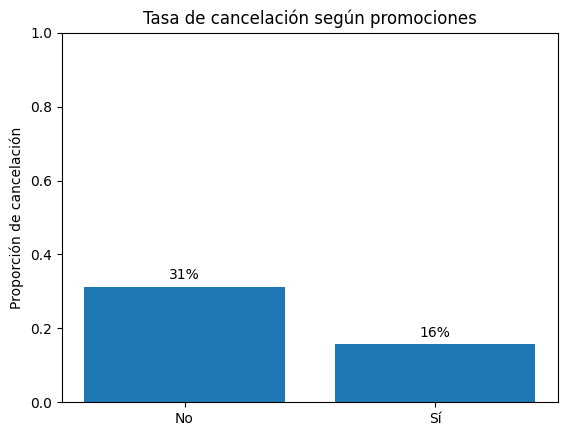

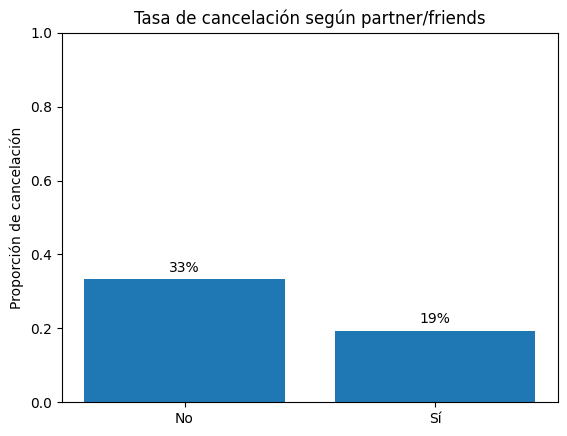

In [14]:
# PREGUNTA 1: ¿TENER AMIGOS REFERIDOS O ACCEDER A PROMOCIONES DISMINUYE LA PROBABILIDAD DE QUE UN CLIENTES CANCELE SU MEMBRESÍA?
# Esta pregunta se encuentra respondida en la sección superior del enunciado.

# En la solución a esta pregunta se utilizaron dos "gráficos de barras" para ofrecer una lectura rápida y precisa de la tasa de cancelación en cada grupo.

# Se ejecutó ".groupby" para separar a los clientes en dos grupos: los que accedieron (1) y los que no (0), a una promoción.

# Tasa de cancelación de clientes que tomaron promociones
promo_churn = df.groupby('promo_friends', observed=True)['churn'].mean().reset_index() #Se calculó el promedio de la tasa de cancelación "churn"
plt.bar(promo_churn['promo_friends'], promo_churn['churn']) # Se crea el gráfico indicando la variable 'promo_friends' para el eje "X" y la variable "churn o cancelación" para eje "Y".
plt.xticks([0,1], ["No", "Sí"]) # Se asignan etiquetas a los números 0 y 1, para que se muestren como "No" y "Si".
plt.title("Tasa de cancelación según promociones") # Se le asigna un titulo al eje "X"
plt.ylabel("Proporción de cancelación") # Se le asigna un titulo al eje "Y"
plt.ylim(0,1) # Se define que el rango a mostrar vaya desde el 0 al 100.

for i, v in enumerate(promo_churn['churn']):   # con el comando "enumerate" se hace un recorrido de la lista obteniendo la posicion "i" y el valor "v", de cada elemento.
    plt.text(i, v + 0.02, f"{v:.0%}", ha='center') # Se asigna un texto encima de cada barra, mostrando el porcentaje centrado horizontalmente.

plt.show() # Muestra el gráfico
 

# Tasa de cancelación de clientes que ocupan el beneficio partner/friends
partner_churn = df.groupby('partner', observed=True)['churn'].mean().reset_index()
plt.bar(partner_churn['partner'], partner_churn['churn'])
plt.xticks([0,1], ["No", "Sí"])
plt.title("Tasa de cancelación según partner/friends")
plt.ylabel("Proporción de cancelación")
plt.ylim(0,1)

for i, v in enumerate(partner_churn['churn']):
    plt.text(i, v + 0.02, f"{v:.0%}", ha='center')

plt.show()

C:\Users\inaro\AppData\Local\Temp\ipykernel_20860\3636023861.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  near_churn = df.groupby('near_location')['churn'].mean().reindex([0,1]) # Se ejecutó ".groupby" para separar a los clientes en dos grupos, viven lejos (0) y viven cerca (1), se calcula el promedio de cancelación con .mean y se ordenan los resultados desde más lejos a más cerca con: ".reindex([0,1])"


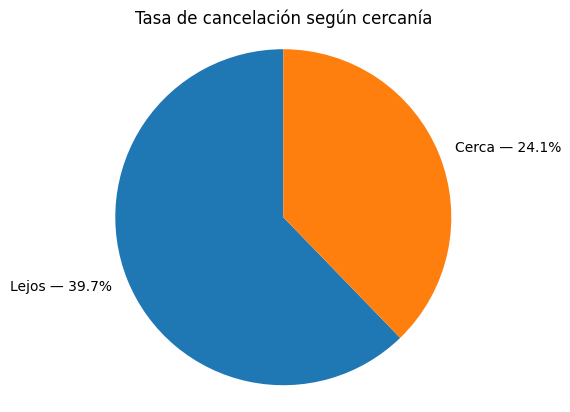

In [15]:
# PREGUNTA 2: ¿LOS CLIENTES QUE VIVEN CERCA DEL GIMNASIO TIENEN MENOR PROBABILIDAD DE CANCELAR SU MEMBRESÍA QUE LOS QUE VIVEN MÁS LEJOS?
# Esta pregunta se encuentra respondida en la sección superior del enunciado, para mantener el orden del ejercicio.

# Para resolver esta pregunta se utilizó el gráfico "pie chart" que dado a que solo se representan dos categorias y con una diferencia de porcentajes alta, resultó apropiada su aplicación.

near_churn = df.groupby('near_location')['churn'].mean().reindex([0,1]) # Se ejecutó ".groupby" para separar a los clientes en dos grupos, viven lejos (0) y viven cerca (1), se calcula el promedio de cancelación con .mean y se ordenan los resultados desde más lejos a más cerca con: ".reindex([0,1])" 
labels = [f"Lejos — {near_churn.loc[0]:.1%}", f"Cerca — {near_churn.loc[1]:.1%}"] # Se asignan las etiquetas de texto en el gráfico

plt.pie(near_churn.values, labels=labels, startangle=90) # Se crea el gráfico circular de la tasa de cancelación, cada "pedazo" representa la tasa de "lejos y cerca"
plt.title("Tasa de cancelación según cercanía") # Se le asigna un titulo
plt.axis('equal')  #Se grafica el círculo perfecto
plt.show() # Se muestra el gráfico

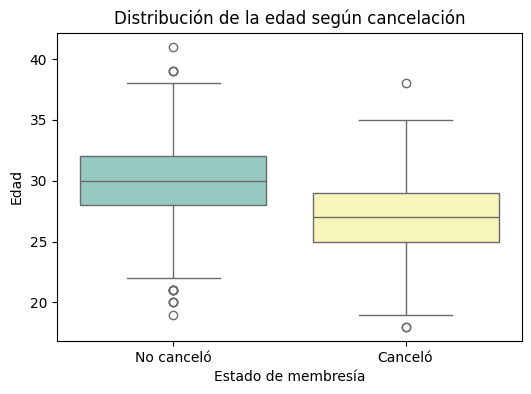

In [16]:
# PREGUNTA 3: ¿EXISTE RELACIÓN ENTRE LA EDAD DE LOS CLIENTES Y LA PROBABILIDAD DE QUE ABANDONEN EL GIMNASIO? #Esta pregunta se encuentra respondida en la sección superior del enunciado, para mantener el orden del ejercicio.

#En este caso se usó una caja de diagramas o gráfico boxplot, para representar la concentración de los datos según el rango etario. 

plt.figure(figsize=(6,4)) # Se crea la figura asignando dimensiones
sns.boxplot(x='churn', y='age', data=df, hue='churn', palette="Set3", legend=False) # Se asigna a "x" la variable de "Cancelación" y al eje "y" la edad. Se seleccionó la paleta de colores del gráfico.
plt.xticks([0,1], ["No canceló", "Canceló"]) # Se le asigna nombre a "0 y 1" 
plt.title("Distribución de la edad según cancelación") # Se asigna título al gráfico
plt.xlabel("Estado de membresía") # Se asigna etiqueta al eje "x"
plt.ylabel("Edad") # Se asigna etiqueta al eje "y"
plt.show() 

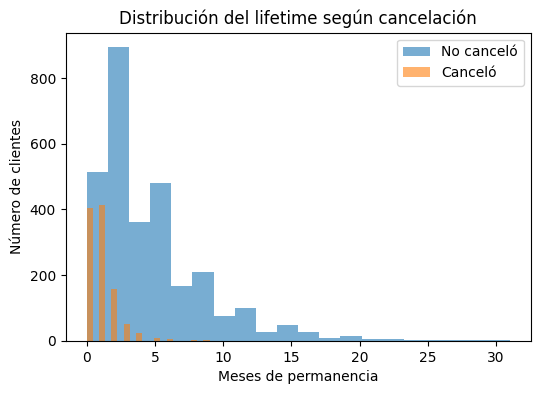

In [17]:
# PREGUNTA 4: ¿OFRECER CONTRATOS MÁS LARGOS GARANTIZA FIDELIZAR A LOS CLIENTES O SOLO RETRASA LA CANCELACIÓN DE SU MEMBRESÍA? #Esta pregunta se encuentra respondida en la sección superior del enunciado, para mantener el orden del ejercicio.

# En esta respuesta se aplicó un Histograma sobre la variable "lifetime" en función a la tasa de cancelación, detallando la tasa de abandono a lo largo del tiempo. 

plt.figure(figsize=(6,4)) # Se crea la figura del histograma 
plt.hist(df[df['churn']==0]['lifetime'], bins=20, alpha=0.6, label="No canceló") # Se crea un histograma tomando de la tasa de cancelación los clientes que "no cancelaron" y se asocia al tiempo de permanencia.
plt.hist(df[df['churn']==1]['lifetime'], bins=20, alpha=0.6, label="Canceló") # Se crea un histograma tomando de la tasa de cancelación los clientes que "cancelaron" y se asocia al tiempo de permanencia.
plt.title("Distribución del lifetime según cancelación") # Se asigna titulo al gráfico
plt.xlabel("Meses de permanencia")  # Se asigna etiqueta al eje "x"
plt.ylabel("Número de clientes") # Se asigna etiqueta al eje "y"
plt.legend() # Se ejecuta para mostrar la leyenda de los colores de las variables graficadas.
plt.show()

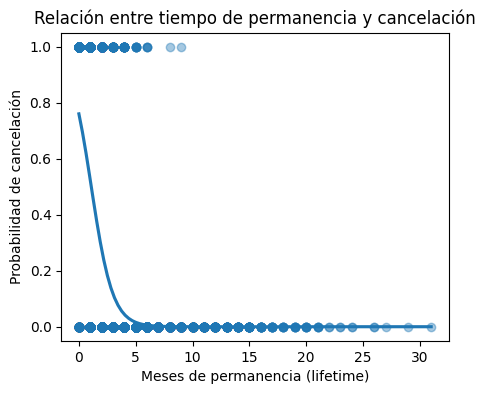

In [18]:
# PREGUNTA 5: ¿EL TIEMPO DE PERMANENCIA DE UN CLIENTE EN EL GIMNASIO ES UN INDICADOR CONFIABLE PARA ANTICIPAR SI SEGUIRÁ O SE DARÁ DE BAJA? #Esta pregunta se encuentra respondida en la sección superior del enunciado, para mantener el orden del ejercicio.

# Para aplicar técnicas de analisis efectivas de acuerdo a las variables, se ejecutó un gráfico scatterpolt con curva logistica, donde la línea muestra la probabilidad de cancelación en relación al tiempo de permanencia.
# Con esta técnica se pudo estudiar la "permanencia o lifetime" como variable númerica continua en función a la varible "Cancelación o churn" que es binaria.

plt.figure(figsize=(5,4)) # Se definió la dimensión del gráfico
sns.regplot( # Se crea con Seaborn un gráfico de dispersión
    x='lifetime', # Se asigna al eje horizontal los meses de permanencia
    y='churn', # Se asigna al eje vertical la variable de cancelación
    data=df, 
    logistic=True, # Se crea una curva logística ideal para la variable de cancelación (0/1)
    ci=None,   # Sin banda de confianza  para que el gráfico quede más limpio
    scatter_kws={'alpha':0.4}  # Se dibujan puntos semitransparentes
)
plt.title("Relación entre tiempo de permanencia y cancelación")
plt.xlabel("Meses de permanencia (lifetime)")
plt.ylabel("Probabilidad de cancelación")
plt.show()

# 3. ¡Vamos con el ML... ¿Qué? ¿Hay que preparar los datos primero?

⁉️ **Consideración:** En las siguientes preguntas harás clusterización y aprendizaje de máquina... prepara tus datos pensando en los modelos que utilizarás. Acá se toman los datos limpios y se pasan a numérico, se cambian las escalas, se agregan columnas para mejorar los resultados de los modelos, etc. Justifica todas tus decisiones.

ℹ️ **HINT:** ¿*Encoding*? ¿Normalización? ¿*Feature Engineering*?

---

✅ **Explicación:**

[ En este paso se prepararon los datos aplicando "Encoding" a las variables categóricas binarias, transformandolas a 0/1 en las columnas: 'gender','near_location','partner','promo_friends','phone','group_visits'. Se realizó One-Hot Encoding en la columna 'contract_period' ya que representaba valores especificos de 1,6 y 12 meses siendo conveniente pasarla a un valor númerico continuo ejecutando "drop_first=True para evitar colinealidad con la columna de un mes, asi quedan dos columnas (6 y 12) entendiendose que si el contrato no es de esos rangos entonces corresponde a contrato de un mes. Para garantizar que las variables se mantengan en la misma escala se ejecutó "Normalización" con MinMaxScaler en 'age','lifetime','avg_additional_charges_total','month_to_end_contract', 'avg_class_frequency_total', 'avg_class_frequency_current_month'. Se crearon dos nuevas variables para detectar cambios de comportamientos del cliente y tener una mejor interpretación de la permanencia, ejecutando "Feature Engineering": 'class_freq_ratio' y 'lifetime_months', con esto se analiza la asistencia reciente en comparación con la asistencia historica del cliente, lo que es útil para anticiparse a un posible abandono].

In [19]:
#Se trabajará con una copia del dataframe para no modificar la original
df_ml = df.copy()

#Verificando el tipo de columnas
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   gender                             4000 non-null   category
 1   near_location                      4000 non-null   category
 2   partner                            4000 non-null   category
 3   promo_friends                      4000 non-null   category
 4   phone                              4000 non-null   category
 5   contract_period                    4000 non-null   int64   
 6   group_visits                       4000 non-null   category
 7   age                                4000 non-null   int64   
 8   avg_additional_charges_total       4000 non-null   float64 
 9   month_to_end_contract              4000 non-null   float64 
 10  lifetime                           4000 non-null   int64   
 11  avg_class_frequency_total          4000 non

In [20]:
# Se transformó las siguientes variables categoricas a númericas para prepararlas para el ML:
# Se aplicó Encoding

cat_cols = ['gender','near_location','partner','promo_friends','phone','group_visits'] #Se eligieron todas las columnas categoricas

le = LabelEncoder() #Se asignó un número a cada categoria
for c in cat_cols:
    df_ml[c] = le.fit_transform(df_ml[c]) #Se hace un recorrido de todas las variables reemplazando la información categorica por númerica

df_ml[cat_cols].head() #Se muestra el resultado de la transformación

,gender,near_location,partner,promo_friends,phone,group_visits
0,1,1,1,1,0,1
1,0,1,0,0,1,1
2,0,1,1,0,1,0
3,0,1,1,1,1,1
4,1,1,1,1,1,0


In [21]:
df_ml = df.copy() # Se realizó una copia porque la transformación de la columna 'contract_period' estaba dando error.
#Por lo que se limpió de cualquier alteración previa. Se aplicó en las celdas siguientes One-Hot Enconding.

In [22]:
#Antes de ejecutar la transformación se verificó que la variable exista (despues de la limpieza y transformaciones que se realizaron en pasos anteriores)

assert 'contract_period' in df_ml.columns, "No está contract_period en df_ml" #Si no existiera arrojará un mensaje más claro
print("Valores únicos de contract_period:", sorted(df_ml['contract_period'].unique())) #Se revisan los valores unicos para confirmar el valor de las variables

Valores únicos de contract_period: [np.int64(1), np.int64(6), np.int64(12)]


In [23]:
#Se aplicó la tecnica de One-Hot Encoding para la columna "contract_period" debido a que muestra diferentes meses o periodos de tiempo, con esto se crean varias columnas binarias, una por categoria/periodo.

df_ml['contract_period'] = df_ml['contract_period'].astype('category') # Se prepara para ML indicando que la columna posee distintas categorias

df_ml = pd.get_dummies(df_ml, columns=['contract_period'], #Se aplica One-Hot Enconding 
                       prefix='contract', drop_first=True)  #Este comando evita la duplicidad o colinealidad entre columnas"drop_first=True" eliminando la columna de 1 mes.

print("¿Existe contract_period después del OHE?:", 'contract_period' in df_ml.columns) #Se verifica que la columna transformada ya no esté. Y se visualizan las dummies nuevas.
print("Dummies creadas:",
      [c for c in df_ml.columns if c.lower().startswith('contract_')])

df_ml.head() #Se muestra el encabezado con el resultado

¿Existe contract_period después del OHE?: False
Dummies creadas: ['contract_6', 'contract_12']


,gender,near_location,partner,promo_friends,phone,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn,contract_6,contract_12
0,1,1,1,1,0,1,29,14.227470,5.0,3,0.020398,0.000000,0,True,False
1,0,1,0,0,1,1,31,113.202938,12.0,7,1.922936,1.910244,0,False,True
2,0,1,1,0,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,False,False
3,0,1,1,1,1,1,33,62.669863,12.0,2,3.205633,3.357215,0,False,True
4,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0,False,False


In [24]:
# Se aplicará la técnica de Normalización ya que las variables tienen escalas distintas.

num_cols = [ 'age','lifetime','avg_additional_charges_total','month_to_end_contract', 'avg_class_frequency_total', 'avg_class_frequency_current_month']
num_cols = [c for c in num_cols if c in df_ml.columns] # Se aplica filtro para que se transformen solo aquellas que estn en el dataset

scaler = MinMaxScaler() 
df_ml[num_cols] = scaler.fit_transform(df_ml[num_cols]) #Se transorma cada variable a un rango de 0 a 1.

print("Columnas normalizadas:", num_cols)
print(df_ml[num_cols].describe().T)  # Se ejecuta describe para confirmar que están en 0,1

df_ml.head

Columnas normalizadas: ['age', 'lifetime', 'avg_additional_charges_total', 'month_to_end_contract', 'avg_class_frequency_total', 'avg_class_frequency_current_month']
                                    count      mean       std  min       25%  \
age                                4000.0  0.486272  0.141668  0.0  0.391304   
lifetime                           4000.0  0.120153  0.120944  0.0  0.032258   
avg_additional_charges_total       4000.0  0.265721  0.174417  0.0  0.124394   
month_to_end_contract              4000.0  0.302068  0.381027  0.0  0.000000   
avg_class_frequency_total          4000.0  0.311939  0.161404  0.0  0.196039   
avg_class_frequency_current_month  4000.0  0.287476  0.171294  0.0  0.156668   

                                        50%       75%  max  
age                                0.478261  0.565217  1.0  
lifetime                           0.096774  0.161290  1.0  
avg_additional_charges_total       0.246310  0.381581  1.0  
month_to_end_contract        

<bound method NDFrame.head of      gender near_location partner promo_friends phone group_visits       age  \
0         1             1       1             1     0            1  0.478261   
1         0             1       0             0     1            1  0.565217   
2         0             1       1             0     1            0  0.434783   
3         0             1       1             1     1            1  0.652174   
4         1             1       1             1     1            0  0.347826   
...     ...           ...     ...           ...   ...          ...       ...   
3995      1             1       1             0     1            0  0.652174   
3996      0             1       0             0     1            1  0.478261   
3997      1             1       1             1     1            0  0.434783   
3998      0             1       1             1     1            0  0.608696   
3999      1             0       1             0     0            1  0.521739   

      avg

In [25]:
# Se aplicó Feature Engineering generando dos nuevas variables: 'class_freq_ratio' y 'lifetime_months', con esto se analiza la asistencia reciente en comparación con la asistencia historica del cliente.
#Indicando que si el "ratio" esta cerca de "1" el cliente tiene una asistencia constante, si el "ratio" es mayor que "1" el cliente asiste más de lo que suele ir
#y si es menor a "1" el cliente ha bajado su frecuencia y es posible abandono.

df_ml['class_freq_ratio'] = (
    df_ml['avg_class_frequency_current_month'] / (df_ml['avg_class_frequency_total'] + 1e-6)) #Se creo una comparación de la frecuencia mensual y total del cliente

df_ml['lifetime_months'] = df_ml['lifetime'] / 30.0 #Se realiza la conversión a meses de permanencia

print(df_ml[['class_freq_ratio','lifetime_months']].head()) #Se muestran algunas columnas con el resultado

   class_freq_ratio  lifetime_months
0          0.000000         0.003226
1          0.973499         0.007527
2          0.915345         0.002151
3          1.026308         0.002151
4          0.985415         0.003226


# 4. ¡Grupos everywhere!

⁉️ **Consideración:** Utiliza técnicas de clusterización para encontrar grupos dentro de tus datos. Recuerda colorear tus gráficos correctamente para que podamos ver los grupos. Sí, debes de graficar tus resultados. ¿En 2D, 3D, 4D? Queda a tu decisión. Recuerda que solo puedes usar métodos de clusterización de `sklearn`.

ℹ️ **HINT 1:** No olvides que cada método es diferente. ¿Justificarás por qué elegiste ese método?

ℹ️ **HINT 2:** No olvides explicar cómo eliges tus hiperparámetros. 

ℹ️ **HINT 3:** ¿No encuentras grupos? ¿Sabías que PCA y otras técnicas de reducción de dimensionalidad son útiles para *clustering*?

---

✅ **Explicación:**

[Como primer paso se separó la columna objetivo para realizar clustering, se utilizó la técnica del codo para determinar el valor de K=4, sin embargo al ejecutar la técnica de K-Means resultaron grupos muy desbalanceados y se probó con K=3 para trabajar con una mayor concentración de datos. Para visualizar estos grupos se empleó PCA con gráfico en 2D y como verificación/complementación, se calcularon los promedios de las varibles númericas por cluster y el promedio de cancelación. Como resultado de estas técnicas se pudo llegar a la conclusión que la base de datos es bastante homogenea y las tecnicas de clustering no aportaron una segmentación con diferencias muy marcadas, ya que, la mayoria de los clientes se concentraron en un mismo cluster (0), comportamiento similar. Lo más valioso de este análisis fue confirmar que la tasa de cancelación global es del 26% y que las estrategias irían enfocadas a este grupo. ]

In [26]:
#Datos para el Clustering sin la columna objetivo: Churn

X_cluster = df_ml.drop(columns=['churn'])  # Se indica que para la matriz de entrada del Clustering se ocupen todas las columnas exceto "Churn" que es el label.
print("Shape X_cluster:", X_cluster.shape)

Shape X_cluster: (4000, 16)


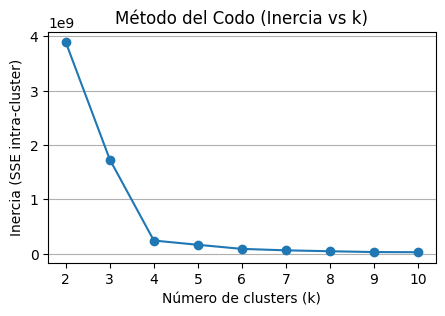

In [27]:
#Se aplica el Método del codo para seleccionar el valor de K, donde el punto de inflexión de la curva fue notoriamente = 4.

inertia = [] 
K = range(2, 11) #Para encontrar un punto óptimo se prueba con un rango de 2 a 10 clusters.
for k in K: 
    km = KMeans(n_clusters=k, n_init='auto', random_state=42) #Se crea un modelo de KMeans y se indica que realice las inicializaciones de forma automática.  
    km.fit(X_cluster) #Se utilizaron todas las variables de clustering para entrenar el modelo
    inertia.append(km.inertia_) #Se obtiene la inercia del modelo entrenado

plt.figure(figsize=(5,3)) #Se crea la figura para el gráfico
plt.plot(list(K), inertia, 'o-') #Se dibuja la curva de inercia vs K, convirtiendo con "list(K)" el rango en lista para graficar
plt.title("Método del Codo (Inercia vs k)") # Titulo del gráfico
plt.xlabel("Número de clusters (k)") # Etiqueta del del eje "X"
plt.ylabel("Inercia (SSE intra-cluster)") # Etiqueta del eje "Y"
plt.grid(True, axis='y') # Se visualizan las lineas guias en el eje "Y"
plt.show() # Se muestra el gráfico

In [28]:
# Se realiza el entrenamiento final de K-Means usando K=4. 
k_final = 4

kmeans = KMeans(n_clusters=k_final, n_init='auto', random_state=42)
clusters = kmeans.fit_predict(X_cluster)

df_ml['cluster'] = clusters

print("Tamaño de cada cluster:")
print(df_ml['cluster'].value_counts().sort_index())

Tamaño de cada cluster:
cluster
0    3977
1       6
2      15
3       2
Name: count, dtype: int64


In [29]:
# Debido a que el modelo K-Means quedó muy desequilibrado, se probará con otro valor, K = 3

k_final = 3
kmeans = KMeans(n_clusters=k_final, n_init='auto', random_state=42)
clusters = kmeans.fit_predict(X_cluster)

df_ml['cluster'] = clusters

print("Tamaño de cada cluster:")
print(df_ml['cluster'].value_counts().sort_index())


Tamaño de cada cluster:
cluster
0    3977
1       5
2      18
Name: count, dtype: int64


In [30]:
# Se ejecuta PCA para graficar con K= 3 y visualizar como se distribuyen en un plano. 

pca = PCA(n_components=2, random_state=42) # Se redujo la dimensionalidad a dos componentes principales para visualizar los cluster en 2D
X_pca = pca.fit_transform(X_cluster)

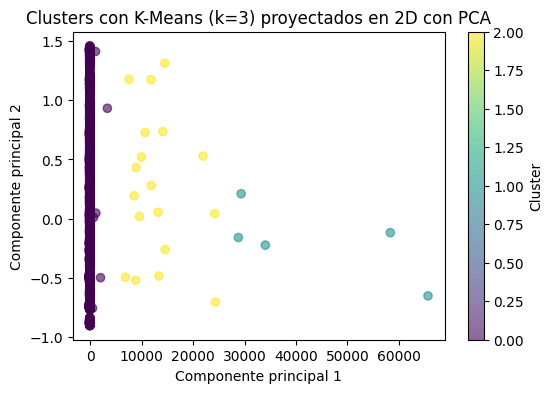

In [31]:
plt.figure(figsize=(6,4)) #Se crea la figura en el espacio
plt.scatter(
    X_pca[:,0], X_pca[:,1], # Se asignan las coordenadas en los dos primeros componentes
    c=df_ml['cluster'],  # Se define el color según el cluster asignado
    cmap='viridis',   # Se elige una paleta de colores para mejor interpretación visual
    alpha=0.6)   # Se define la transparencia para ver la densidad

plt.xlabel("Componente principal 1") 
plt.ylabel("Componente principal 2")
plt.title("Clusters con K-Means (k=3) proyectados en 2D con PCA")
cbar = plt.colorbar()
cbar.set_label("Cluster") # Se asigna una barra de colores para identificar cada cluster
plt.show()

# Se encontró que el cluster 0 agrupa la gran mayoría de los clientes, lo que evidencia que la base de datos es bastante homogénea.
# Mientras que los clusters 1 y 2 corresponden a grupos muy pequeños representando casos atipícos o outliers.

In [32]:
# Se cálculo la tabla de promedios por cluster (0,1 y 2) para verificar con números lo observado en el gráfico PCA 2D

numeric_cols = X_cluster.select_dtypes(include=[np.number]).columns

# Media por cluster solo en numéricas
cluster_profile = df_ml.groupby('cluster')[numeric_cols].mean().round(3)
print(cluster_profile)

           age  avg_additional_charges_total  month_to_end_contract  lifetime  \
cluster                                                                         
0        0.486                         0.266                  0.302     0.120   
1        0.504                         0.214                  0.291     0.194   
2        0.481                         0.296                  0.384     0.138   

         avg_class_frequency_total  avg_class_frequency_current_month  \
cluster                                                                 
0                            0.314                              0.289   
1                            0.000                              0.043   
2                            0.000                              0.013   

         class_freq_ratio  lifetime_months  
cluster                                     
0                   3.153            0.004  
1               43361.778            0.006  
2               13139.355            0.005  


# Se puede observar que el cluster 0 agrupa la mayoria de los clientes siendo este grupo los casos más típicos con una frecuencia moderada. Mientras que los clusters 1 y 2 representan pocos clientes con valores muy altos en la variable "class_freq_ratio", lo que los convierte en casos atípicos.

# Los promedios calculados muestran que los tres grupos son similares en cuanto a "edad, gastos/servicios adicionales, contrato y lifetime" confirmando que es una base homogénea.

In [33]:
# BONUS: +0.5 puntos.
# Si no harás el bonus, elimina esta sección.

# Se calculó la tasa de cancelación por clusters,identificando que el clusters 1 y 2 por tener pocos clientes no son estadisticamente representativos.
# Mientras que el cluster 0 que es el grupo con mayor información, representa el 26% de las cancelaciones. 

if 'churn' in df_ml.columns:
    print("Tasa de churn por cluster:")
    print(df_ml.groupby('cluster')['churn'].mean().round(3))

Tasa de churn por cluster:
cluster
0    0.266
1    0.400
2    0.000
Name: churn, dtype: float64


# 5. ¿Podemos predecir algo con estos datos? Demostremos nuestra experiencia.

⁉️ **Consideración:** Es la hora de aplicar modelos de clasificación o regresión (`sklearn`) a los datos. Enfócate en ser ordenado y seguir todos los pasos: datos, entrenamiento, validación, testeo, interpretación, etc. Debes de explicar a fondo tus decisiones de modelo, parámetros, interpretación de resultados, medidas de rendimiento, etc.

ℹ️ **HINT 1:** ¿Habías escuchado de Validación Cruzada? ¿Has escuchado de `GridSearchCV`?

ℹ️ **HINT 2:** ¿Te fjaste en el *overfitting*?

ℹ️ **HINT 3:** ¿Por qué elegiste ese modelo? Puedes utilizar cualquier modelo de `sklearn`.

ℹ️ **HINT 4:** Se recomienda que comparen varios modelos. ¿Leíste la documentación de `sklearn`?

---

✅ **Explicación:**

[Esta respuesta fue bastante de compleja de desarrollar, sin embargo se logró mantener una secuencia lógica en cada paso. Primeramente se verificó los tipos de celdas del DF hasta este punto del análisis para transformar las columnas categóricas a númericas con OHE creando dummies. Se realizó una preparación previa de los datos, separando la columna objetivo del resto de variables, se dividió la data en dos sets, Train/Val un 80% y testeo un 20% logrando un set lo suficientemente grande para entrenar y un set amplio como representación para evaluar. Para agilizar el proceso de entrenamiento se ejecutó "rf_variants" donde se unieron las variantes propuestas, para obtener un promedio confiable se propuso 5 Trials abarcando parametros superficiales, equilibrados, profundos e intermedios. Las trials fueron entrenadas con Random Forest, se realizó validación cruzada y se crearon promedios que calcularon el mejor Trial que fue: Trial 1, con F1: 0.83 y Gap: 0.17, que según la documentación de "scikit-learn" estaría apuntando a un sobreajuste, el Trial 2 sin embargo tiene un F1 de 0.82 y Gap: 0.14 que favorece la generalización. Por deducción propia se determinó ocupar el Trial 2, más equilibrado, al obtener los resultados alcanzó un Accuracy de 92%, F1 en churn 0.85 y ROC-AUC de 97% ofreciendo una buena base para estrategias de retención. Para finalizar se calcularon las variables a considerar como más estrategicas a nivel de negocio, ejecutando "feature_importances_" siendo las más influyentes: lifetime, frecuencia, edad, contrato, estas variables son de gran relevancia porque alertan de los clientes con menor asistencia o menor permanencia puedan tener mayor riesgo de cancelación. ]

In [34]:
#Verificación de tipos de datos
df.dtypes

gender                               category
near_location                        category
partner                              category
promo_friends                        category
phone                                category
contract_period                         int64
group_visits                         category
age                                     int64
avg_additional_charges_total          float64
month_to_end_contract                 float64
lifetime                                int64
avg_class_frequency_total             float64
avg_class_frequency_current_month     float64
churn                                   int64
dtype: object

In [76]:
# Ejecución de One-Hot Encoding a todas las columnas categóricas para entrenar en ML

cat_cols = df.select_dtypes(include=["category", "object"]).columns.tolist() #Se consideran todas las columnas de tipo "category", "object"
cat_cols = [c for c in cat_cols if c != "churn"] # Exceptuando la columna churn que es la variable objetivo

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True) # Se aplica el OHE y se generan las columnas binarias/dummies

print("Shape df_encoded:", df_encoded.shape) # Se crea el nuevo DF con las variables listas
df_encoded.head() # Se muestra el resultado

Shape df_encoded: (4000, 14)


,contract_period,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn,gender_1,near_location_1,partner_1,promo_friends_1,phone_1,group_visits_1
0,6,29,14.227470,5.0,3,0.020398,0.000000,0,True,True,True,True,False,True
1,12,31,113.202938,12.0,7,1.922936,1.910244,0,False,True,False,False,True,True
2,1,28,129.448479,1.0,2,1.859098,1.736502,0,False,True,True,False,True,False
3,12,33,62.669863,12.0,2,3.205633,3.357215,0,False,True,True,True,True,True
4,1,26,198.362265,1.0,3,1.113884,1.120078,0,True,True,True,True,True,False


In [36]:
# Separación de la variable objetivo "Churn". Se identifican 13 columnas de variables predictoras.

target_col = "churn"  
X = df_encoded.drop(columns=[target_col]) #Variables predictorias
y = df_encoded[target_col] #Variable objetivo

print("X shape:", X.shape, "| y shape:", y.shape) # Se muestra el resultado

X shape: (4000, 13) | y shape: (4000,)


In [77]:
# Se dividieron los datos en un set de entrenamiento/validación y test, quedando: Train+Val (80%) y Test (20%)

# El resultado mostró que el set Train+Val es de 3200 filas de clientes y 13 columnas de variables, mientras que el 
#set de Test tiene 800 filas de clientes y las mismas columnas predictorias

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train_val.shape, X_test.shape

((3200, 13), (800, 13))

In [49]:
# Se prepararon las variantes de hiperparámetros uniendolas en "rf_variants", para trabajar de un modo ordenado al ejecutar Random Forest 
# y evaluarlas todas con validación cruzada.

rf_variants = [
   
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1, "max_features": "sqrt"},  # Se escogieron estos parametros como punto de partida
    
    {"n_estimators": 300, "max_depth": 12,   "min_samples_split": 5, "min_samples_leaf": 2, "max_features": "sqrt"}, # Con estos parámetros se buscó hacer un análsis más equilibrado 
    
    {"n_estimators": 400, "max_depth": 20,   "min_samples_split": 10,"min_samples_leaf": 4, "max_features": "log2"}, # Se buscó abarcar mayor información, más complejidad y profundidad.
   
    {"n_estimators": 250, "max_depth": 16,   "min_samples_split": 5, "min_samples_leaf": 2, "max_features": "sqrt"},  # Se intentó crear un trial intermedio, menos compleja pero con profundidad. 
    
    {"n_estimators": 150, "max_depth": 10,   "min_samples_split": 2, "min_samples_leaf": 1, "max_features": "log2"}, # El objetivo es crear un contraste de comparación con las variantes más complejas y balanceadas.
]
len(rf_variants)

5

In [78]:
# Se creó el esquema de validación cruzada (5 folds): Para que el modelo entrene y evalúe 5 veces manteniendo un balance de "Churn"
#para que cada muestra sea representativa del dataset completo.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv

StratifiedKFold(n_splits=5, random_state=0, shuffle=True)

In [79]:
# En este paso se ejecuta Random Forest, se evalua y comparan las variantes para validación cruzada y se generan métricas para 
#elegir la mejor.

def evaluate_rf_variants_cv(variants, X, y, cv, scoring=("f1","precision","recall","accuracy","roc_auc")):
    rows = []
    for i, params in enumerate(variants, start=1): # Se recorre cada hiperparametro de las 5 triales
        rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params) # Se ejecuta Random Forest

        cv_res = cross_validate( # Se aplica la validación cruzada y se generan métricas en cada fold.
            rf, X, y,
            cv=cv,
            scoring=scoring,    
            n_jobs=-1,
            return_train_score=True)

        row = { # Se calculan los promedios de las métricas resultantes de la validacion cruzada
            "trial": i,
            "params": params,
            "f1_mean":        np.mean(cv_res["test_f1"]),
            "f1_std":         np.std(cv_res["test_f1"]),
            "precision_mean": np.mean(cv_res["test_precision"]),
            "recall_mean":    np.mean(cv_res["test_recall"]),
            "acc_mean":       np.mean(cv_res["test_accuracy"]),
            "roc_auc_mean":   np.mean(cv_res["test_roc_auc"]),
            "f1_train_mean":  np.mean(cv_res["train_f1"]),   # para chequear overfitting
        }
        rows.append(row)

    df_out = pd.DataFrame(rows).sort_values("f1_mean", ascending=False).reset_index(drop=True) # Resulta una tabla de todas las variantes de mejor a peor.
    return df_out

In [81]:
# Ejecución de validación cruzada por cada variante sobre TrainVal.

# Todas las variables tienen modelos consistentes, se puede verificar que el Trial 1 tiene el mayor F1, mejor balance pero el F1 Train fue de 1.00 lo 
#que indica sobreajuste.

df_cv = evaluate_rf_variants_cv(rf_variants, X_train_val, y_train_val, cv)
df_cv

,trial,params,f1_mean,f1_std,precision_mean,recall_mean,acc_mean,roc_auc_mean,f1_train_mean
0,1,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.832299,0.017469,0.866220,0.802081,0.914375,0.971204,1.000000
1,5,"{'n_estimators': 150, 'max_depth': 10, 'min_sa...",0.831432,0.020536,0.863613,0.802109,0.913750,0.969296,0.972441
2,4,"{'n_estimators': 250, 'max_depth': 16, 'min_sa...",0.825523,0.018668,0.869357,0.786780,0.911875,0.970770,0.966644
3,2,"{'n_estimators': 300, 'max_depth': 12, 'min_sa...",0.824257,0.018085,0.861984,0.790317,0.910625,0.971046,0.960237
4,3,"{'n_estimators': 400, 'max_depth': 20, 'min_sa...",0.816248,0.018639,0.863105,0.775002,0.907500,0.968912,0.912187


In [68]:
# Comparación de variantes F1 y Gap para descartar las más sobreajustadas.

df_cv["gap"] = df_cv["f1_train_mean"] - df_cv["f1_mean"]
df_cv_sorted = df_cv.sort_values(["f1_mean", "gap"], ascending=[False, True]).reset_index(drop=True)
df_cv_sorted.head(10) # Se muestra el top de las más ideales

,trial,params,f1_mean,f1_std,precision_mean,recall_mean,acc_mean,roc_auc_mean,f1_train_mean,gap
0,1,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.832299,0.017469,0.866220,0.802081,0.914375,0.971204,1.000000,0.167701
1,5,"{'n_estimators': 150, 'max_depth': 10, 'min_sa...",0.831432,0.020536,0.863613,0.802109,0.913750,0.969296,0.972441,0.141008
2,4,"{'n_estimators': 250, 'max_depth': 16, 'min_sa...",0.825523,0.018668,0.869357,0.786780,0.911875,0.970770,0.966644,0.141121
3,2,"{'n_estimators': 300, 'max_depth': 12, 'min_sa...",0.824257,0.018085,0.861984,0.790317,0.910625,0.971046,0.960237,0.135979
4,3,"{'n_estimators': 400, 'max_depth': 20, 'min_sa...",0.816248,0.018639,0.863105,0.775002,0.907500,0.968912,0.912187,0.095939


In [69]:
# Selección de la mejor variante según F1 y Gap

# El Trial 1 tuvó el mayor F1 en validación cruzada, pero el gap más alto, lo que indica sobreajuste.
#por criterio no se trabajará con este Trial.

best_row = df_cv_sorted.iloc[0]
best_params = best_row["params"]
best_trial  = best_row["trial"]

print(">> Selección automática")
print("Trial:", best_trial)
print("Parámetros:", best_params)
print("F1 (CV):", round(best_row["f1_mean"], 4), "| gap:", round(best_row["gap"], 4))


>> Selección automática
Trial: 1
Parámetros: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
F1 (CV): 0.8323 | gap: 0.1677


In [70]:
# Se seleccionó manualmente como modelo final el Trial= 2 por balance entre rendimiento y generalización

best_params = df_cv.loc[df_cv["trial"]==2, "params"].iloc[0]
best_trial  = 2

In [73]:
# Se entrena la variante Trial 2 con todos los datos de TrainVal y se ejecuta el test final.

best_params = df_cv.loc[df_cv["trial"]==2, "params"].iloc[0]
best_trial  = 2 # Se toman los parámetros de la variante 2


rf_best = RandomForestClassifier(random_state=42, n_jobs=-1, **best_params) # Se creó el Random Forest con los parametros del trial 2
rf_best.fit(X_train_val, y_train_val)


y_pred_test = rf_best.predict(X_test) # Se aplica el modelo al set de prueba

print(f"[TEST] Reporte de clasificación (Trial={best_trial}):")
print(classification_report(y_test, y_pred_test)) #Se generaron las métricas
print("Matriz de confusión (TEST):")
print(confusion_matrix(y_test, y_pred_test)) #Se genera la matriz de confusión para ver los aciertos y errores


try:
    y_proba_test = rf_best.predict_proba(X_test)[:, 1] # Se calculó ROC-AUC verificando su capacidad de generalización
    print("ROC-AUC (TEST):", roc_auc_score(y_test, y_proba_test))
except Exception as e:
    print("No se pudo calcular ROC-AUC:", e)


[TEST] Reporte de clasificación (Trial=2):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       588
           1       0.87      0.82      0.85       212

    accuracy                           0.92       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.92      0.92       800

Matriz de confusión (TEST):
[[563  25]
 [ 38 174]]
ROC-AUC (TEST): 0.9726768065716852


# El modelo escogido logró un accuracy de 92%, en el set de prueba y un F1= 0.85 para churn, esto indica un buen equilibrio para detectar a los clientes que dan de baja su membresía sin embargo en la matriz de confusión resultó que tuvo un margen de error de 38 clientes que sí cancelaron y no los incluyó. El promedio de ROC-AUC fue de 0.97 lo que confirma el nivel de acertividad.

In [74]:
# Se muestran las variable más importantes en el modelo final (Trial 2)

feat_imp = pd.Series(rf_best.feature_importances_, index=X_train_val.columns).sort_values(ascending=False) #Se extrae del RF los puntajes de importancia de cada columa.
feat_imp.head(15) #Muestra el top 15

lifetime                             0.309555
avg_class_frequency_current_month    0.170316
avg_class_frequency_total            0.128229
age                                  0.119984
contract_period                      0.078575
month_to_end_contract                0.075622
avg_additional_charges_total         0.069028
group_visits_1                       0.013810
partner_1                            0.008913
gender_1                             0.007968
promo_friends_1                      0.007589
near_location_1                      0.006500
phone_1                              0.003910
dtype: float64

# Las variables más importantes a tener en consideración para desarrollar estrategias son lifetime, frecuencia de asistencia mensual y total, edad, contrato.

# 6. ¿Puedes explicar mejor tus resultados? ¡De Junior a Senior!

⁉️ **Consideración:** Para pasar de ser una *Data Scientist Junior* a *Senior* deberás ser muy bueno para interpretar y mejorar los resultados de tu modelo. ¿Qué otras mediciones puedes utilizar? ¿Cómo puedes modificar tus datos? ¿Qué datos te faltan? ¿Qué impacta más a tu predicción? ¿Por qué hay métricas más importantes que otras? ¡Y muchas preguntas más! Ahonda en los resultados de tus modelos.

ℹ️ **HINT 1:** ¿Qué otras métricas existen? ¿Matrices de confusión? ¿Por qué hay clases que funcionan peor?

ℹ️ **HINT 2:** ¿Consideraste la reducción de dimensionalidad?

ℹ️ **HINT 3:** ¿Conoces la librería `SHAP`? ¿O los *Partial Dependece Plots*?

---

✅ **Explicación:**

[ Para concluir, el modelo aplicado logró un buen balance con un umbral de 0.5, Recall 0.82, Precision 0.87 y Accuracy de 0.92
Con un umbral de 0.0 el Recall sube a 1.0, Precisión y Accuracy caen aprox. a 0.27 Entonces el umbral estandar 0.5, es el más apropiado para este caso]

In [83]:
cm = confusion_matrix(y_test, y_pred_test)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for label, acc in zip(rf_best.classes_, per_class_acc):
    print(f"Clase {label}: accuracy={acc:.2f}")
cm

Clase 0: accuracy=0.96
Clase 1: accuracy=0.82


array([[563,  25],
       [ 38, 174]])

Este resultado indica que la clase 0 (no churn/no cancelación) tiene una probabilidad de acierto de 96%, lo que hace al modelo bastante acertivo para predecir quien se queda, sin embargo para el negocio el foco debe estar retener a los que sí cancelan (churn) clase 1 con un accuracy del 82%. 

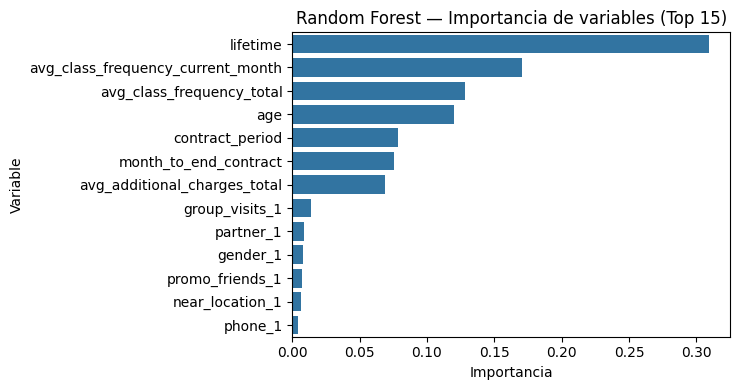

In [90]:
# Se visualizan qué variables pesan más en el modelo final (Trial 2).
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

feat_imp = pd.Series(rf_best.feature_importances_, index=X_train_val.columns).sort_values(ascending=False)
plt.figure(figsize=(7.5,4))
sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
plt.title("Random Forest — Importancia de variables (Top 15)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

El gráfico muestra que la variable más influyente es "lifetime" indicando que los clientes con menor tiempo de permanencia tendrán más riesgo de cancelación y en segundo lugar debe considerarse la asistencia mensual y total concluyendo que los clientes con menor tasa de asistencia son más propensos a dar de baja el plan. Se visualiza que las variables con menor peso pero con un aporte importante son edad, tipo de contrato, meses restantes, cargos adicionales, visitas en grupo, partners, promos, ubicación.

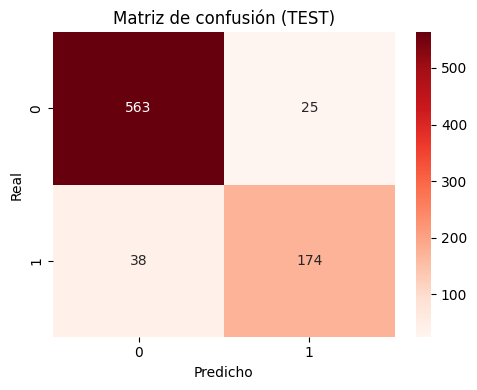

In [91]:
# Se grafica con heatmap la matriz de confusión para identificar FP y FN.

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=rf_best.classes_, yticklabels=rf_best.classes_)
plt.title("Matriz de confusión (TEST)")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


El heatmap muestra una alta prediccion del modelo para detectar a la clase 0 (no churn, 563 aciertos). Sin embargo pierde 38 clientes que sí cancelaron (clase 1) que son los de más importancia para el objetivo del análsis. Detectó 25 clientes como falsos positivos que no se consideran relevantes ya que es mejor prevenir que dejar escapar posibles cancelaciones.

In [93]:
# Se calculó un umbral que cumpla un Recall mínimo en churn (clase 1).

from sklearn.metrics import precision_recall_curve, classification_report, accuracy_score
import numpy as np

y_proba_test = rf_best.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

target_recall = 0.88
mask = recalls[1:] >= target_recall   # alinear con thresholds
if mask.any():
    idx = np.where(mask)[0][0]
else:
    idx = np.argmax(recalls[1:])
thr = thresholds[idx]
rec_at_thr = recalls[1:][idx]
prec_at_thr = precisions[1:][idx]
print(f"Umbral seleccionado: {thr:.3f} | Recall≈{rec_at_thr:.3f} | Precisión≈{prec_at_thr:.3f}")

Umbral seleccionado: 0.000 | Recall≈1.000 | Precisión≈0.273


Este resultado del umbral indica que el modelo marca a casi todos como "churn", lo que no es muy últil porque implicaría intervenir a los clientes innecesariamente. Lo ideal sería utilizar un Umbral intermedio que alcance un recall de 0.88 a 0.90 manteniendo asi una precisión más aceptable.

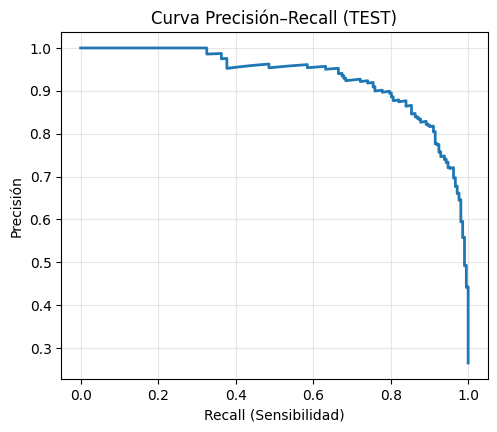

Umbral equilibrado: 0.000 | Recall≈1.000 | Precisión≈0.273


In [96]:
# Se calculan las curvas de Precisión y Recall en función de distintos umbrales

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

# Se realiza la Gráfica de la curva

plt.figure(figsize=(5.5,4.5))
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precisión")
plt.title("Curva Precisión–Recall (TEST)")
plt.grid(True, alpha=0.3)
plt.show()

target_recall = 0.88 # Se determina el primer umbral que cumpla Recall >= 0.88
mask = recalls[1:] >= target_recall   
if mask.any():
    idx = np.where(mask)[0][0]
else:
    idx = np.argmax(recalls[1:])      
thr_bal = thresholds[idx]
rec_bal = recalls[1:][idx]
prec_bal = precisions[1:][idx]

print(f"Umbral equilibrado: {thr_bal:.3f} | Recall≈{rec_bal:.3f} | Precisión≈{prec_bal:.3f}")

In [97]:
# Se calcularon predicciones con el umbral ajustado

y_pred_bal = (y_proba_test >= thr_bal).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("[TEST] Reporte con umbral ajustado")
print(classification_report(y_test, y_pred_bal))

print("Matriz de confusión con umbral ajustado:")
print(confusion_matrix(y_test, y_pred_bal))

[TEST] Reporte con umbral ajustado
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       588
           1       0.27      1.00      0.42       212

    accuracy                           0.27       800
   macro avg       0.13      0.50      0.21       800
weighted avg       0.07      0.27      0.11       800

Matriz de confusión con umbral ajustado:
[[  0 588]
 [  0 212]]


C:\Users\inaro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\inaro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\inaro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [98]:
print(classification_report(y_test, y_pred_bal, zero_division=0))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       588
           1       0.27      1.00      0.42       212

    accuracy                           0.27       800
   macro avg       0.13      0.50      0.21       800
weighted avg       0.07      0.27      0.11       800



En este  caso el modelo detectó a todos como "churn" pero solo un 27% eran acertados, esto no es viable porque indica que se intervengan a todos los clientes aunque no se vayan a ir.

In [99]:
# Se compararon las métricas con el umbral estándar 0.5 vs el umbral elegido por Recall.
from sklearn.metrics import confusion_matrix

def quick_scores(y_true, y_score, thr):
    y_pred = (y_score >= thr).astype(int)
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "thr": thr, "acc": accuracy_score(y_true, y_pred),
        "prec_1": rep["1"]["precision"], "rec_1": rep["1"]["recall"], "f1_1": rep["1"]["f1-score"],
        "FP": fp, "FN": fn, "TP": tp, "TN": tn
    }

base = quick_scores(y_test, y_proba_test, 0.50)
tuned = quick_scores(y_test, y_proba_test, thr)

pd.DataFrame([base, tuned]).round(3)


,thr,acc,prec_1,rec_1,f1_1,FP,FN,TP,TN
0,0.5,0.921,0.874,0.821,0.847,25,38,174,563
1,0.0,0.265,0.265,1.000,0.419,588,0,212,0


Aquí comparamos ambos umbrales siendo 0.5 el mejor balance, recall 0.82 y precisión 0.87 ambos suficientemente altos; En relación con el umbral 0.0 es inviable aunque no se pierda ningún churn genera muchos falsos positivos.

> # ¡NO OLVIDES GUARDAR Y SUBIR EL NOTEBOOK A LA PLATAFORMA CUANDO TERMINES! FORMATO .ipynb

> # ¡NO OLVIDES SUBIR LOS DATOS ORIGINALES A LA PLATAFORMA!